In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('mystyle')
import time
import umap
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [ ]:
df_cardata = pd.read_hdf('f1_data/9157_car_data_2023_Italy_Grand_Prix_Race.h5')
df_cardata
# names = df['name_acronym'].unique()

# No need to extract columns separately, just filter the df directly
# telem = df[['speed', 'rpm', 'n_gear', 'throttle']].loc[df['speed'] > 0]

,date,session_key,n_gear,meeting_key,driver_number,drs,rpm,brake,speed,throttle
0,2023-09-03 12:01:04.442000+00:00,9157,0,1218,1,0,0,0,0,0
1,2023-09-03 12:01:04.762000+00:00,9157,0,1218,1,0,0,0,0,0
2,2023-09-03 12:01:04.922000+00:00,9157,0,1218,1,0,0,0,0,0
3,2023-09-03 12:01:05.122000+00:00,9157,0,1218,1,0,0,0,0,0
4,2023-09-03 12:01:05.322000+00:00,9157,0,1218,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
719615,2023-09-03 14:42:49.034000+00:00,9157,0,1218,81,0,0,104,0,104
719616,2023-09-03 14:42:49.434000+00:00,9157,0,1218,81,0,0,104,0,104
719617,2023-09-03 14:42:49.593000+00:00,9157,0,1218,81,0,0,104,0,104
719618,2023-09-03 14:42:49.833000+00:00,9157,0,1218,81,0,0,104,0,104


In [11]:
df_stints = pd.read_hdf('f1_data/9157_stints_2023_Italy_Grand_Prix_Race.h5')
df_stints.sort_values(by='driver_number', inplace=True)
df_stints

,meeting_key,session_key,stint_number,driver_number,lap_start,lap_end,compound,tyre_age_at_start
2,1218,9157,1,1,1.0,20.0,MEDIUM,0
29,1218,9157,2,1,21.0,51.0,HARD,0
24,1218,9157,2,2,15.0,51.0,HARD,3
11,1218,9157,1,2,1.0,14.0,MEDIUM,3
19,1218,9157,1,4,1.0,22.0,MEDIUM,0
34,1218,9157,2,4,23.0,51.0,HARD,4
16,1218,9157,1,10,1.0,10.0,MEDIUM,0
39,1218,9157,3,10,32.0,51.0,MEDIUM,0
20,1218,9157,2,10,11.0,31.0,HARD,3
5,1218,9157,1,11,1.0,21.0,MEDIUM,0


In [7]:
import json
import pandas as pd

df_laps = pd.read_hdf("f1_data/9157_laps_2023_Italy_Grand_Prix_Race.h5", key="laps")

# # Restore the segment columns from JSON strings back to lists
# for col in ["segments_sector_1", "segments_sector_2", "segments_sector_3"]:
#     if col in df_laps.columns:
#         df_laps[col] = df_laps[col].apply(lambda x: json.loads(x) if pd.notna(x) else None)

In [12]:
df_laps.sort_values(by='driver_number', inplace=True)
df_laps

,meeting_key,session_key,driver_number,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,is_pit_out_lap,lap_duration,segments_sector_1,segments_sector_2,segments_sector_3,st_speed
249,1218,9157,1,14,2023-09-03 13:42:07.242000+00:00,28.223,30.280,28.525,314.0,320.0,False,87.028,"[null, 2048, 2048, 2048, 2048, 2048, 2049, 2049]","[2048, 2048, 2048, 2048, 2048, 2048, 2048]","[2048, 2048, 2048, 2048, 2048, 2048, 2048, 204...",343.0
759,1218,9157,1,41,2023-09-03 14:21:11.497000+00:00,28.079,29.543,28.157,313.0,313.0,False,85.779,"[null, 2048, 2048, 2048, 2048, 2048, 2048, 2048]","[2048, 2048, 2048, 2048, 2048, 2048, 2048]","[2048, 2048, 2049, 2048, 2048, 2048, 2048, 204...",312.0
684,1218,9157,1,37,2023-09-03 14:15:28.829000+00:00,28.074,29.485,28.124,313.0,313.0,False,85.683,"[null, 2048, 2048, 2048, 2048, 2049, 2049, 2048]","[2048, 2048, 2048, 2048, 2048, 2048, 2048]","[2048, 2048, 2049, 2048, 2048, 2048, 2048, 204...",315.0
867,1218,9157,1,47,2023-09-03 14:29:47.022000+00:00,28.058,29.565,28.514,NaN,316.0,False,86.137,"[null, 2048, 2048, 2048, 2048, 2048, 2049, 2048]","[2048, 2048, 2048, 2048, 2048, 2048, 2048]","[2048, 2048, 2048, 2048, 2048, 2048, 2048, 204...",306.0
97,1218,9157,1,6,2023-09-03 13:30:35.109000+00:00,28.700,29.662,28.475,310.0,319.0,False,86.837,"[null, 2049, 2049, 2048, 2048, 2048, 2048, 2048]","[2048, 2048, 2048, 2048, 2048, 2048, 2048]","[2048, 2048, 2048, 2048, 2048, 2048, 2048, 204...",347.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
828,1218,9157,81,44,2023-09-03 14:26:44.415000+00:00,27.968,29.130,28.592,313.0,324.0,False,85.690,"[null, 2048, 2048, 2048, 2048, 2049, 2049, 2048]","[2048, 2048, 2048, 2048, 2048, 2051, 2048]","[2048, 2048, 2048, 2049, 2049, 2048, 2048, 204...",326.0
348,1218,9157,81,19,2023-09-03 13:49:36.065000+00:00,28.545,30.104,28.703,311.0,308.0,False,87.352,"[null, 2048, 2048, 2048, 2048, 2048, 2048, 2048]","[2048, 2048, 2048, 2048, 2048, 2048, 2048]","[2048, 2049, 2048, 2048, 2048, 2048, 2048, 204...",312.0
899,1218,9157,81,48,2023-09-03 14:32:28.755000+00:00,28.089,29.668,28.310,NaN,322.0,False,86.067,"[2049, 2048, 2048, 2048, 2048, 2048, 2048, 2048]","[2048, 2048, 2048, 2048, 2048, 2048, 2048]","[2048, 2048, 2048, 2048, 2049, 2048, 2048, 204...",335.0
291,1218,9157,81,16,2023-09-03 13:45:13.896000+00:00,28.376,29.995,28.830,311.0,306.0,False,87.201,"[2048, 2048, 2049, 2048, 2048, 2048, 2048, 2048]","[2048, 2048, 2048, 2048, 2048, 2048, 2048]","[2048, 2048, 2048, 2048, 2048, 2048, 2048, 204...",320.0


In [5]:
df_weather = pd.read_hdf('f1_data/9157_weather_2023_Italy_Grand_Prix_Race.h5')
df_weather

,date,session_key,wind_direction,meeting_key,wind_speed,rainfall,track_temperature,air_temperature,humidity,pressure
0,2023-09-03 12:01:37.059000+00:00,9157,302,1218,1.8,0,43.2,28.5,45.0,1001.0
1,2023-09-03 12:02:37.058000+00:00,9157,287,1218,2.0,0,43.3,28.6,45.0,1001.2
2,2023-09-03 12:03:37.058000+00:00,9157,269,1218,0.6,0,43.3,28.5,45.0,1001.0
3,2023-09-03 12:04:37.057000+00:00,9157,154,1218,0.8,0,43.3,28.5,45.0,1001.0
4,2023-09-03 12:05:37.056000+00:00,9157,274,1218,0.8,0,42.8,28.4,46.0,1001.0
...,...,...,...,...,...,...,...,...,...,...
151,2023-09-03 14:32:37.552000+00:00,9157,157,1218,1.2,0,41.2,30.0,42.0,1000.2
152,2023-09-03 14:33:37.567000+00:00,9157,179,1218,1.2,0,41.0,30.0,41.0,1000.2
153,2023-09-03 14:34:37.581000+00:00,9157,152,1218,1.6,0,40.8,30.0,41.0,1000.2
154,2023-09-03 14:35:37.581000+00:00,9157,161,1218,1.7,0,40.8,30.0,41.0,1000.2


In [6]:
df = pd.read_csv("Data/bahrain_2023_race_telemetry.csv")
df

FileNotFoundError: [Errno 2] No such file or directory: 'Data/bahrain_2023_race_telemetry.csv'

In [ ]:
team_names = df['team_name'].unique()
print(team_names)

['Red Bull Racing' 'Williams' 'McLaren' 'Alpine' 'Aston Martin' 'Ferrari'
 'Haas F1 Team' 'AlphaTauri' 'Alfa Romeo' 'Mercedes']


In [ ]:
telem = df[['speed', 'rpm', 'throttle']].loc[df['speed'] > 0]
driver_numbers = df['driver_number'].loc[df['speed'] > 0].values
print(np.unique(driver_numbers))

[ 1  2  4 10 11 14 16 18 20 22 23 24 27 31 40 44 55 63 77 81]


In [ ]:
telem

,n_gear,throttle
3559,1,0
3560,1,0
3561,1,0
3562,1,0
3563,1,0
...,...,...
360411,1,0
360412,1,0
360413,1,0
360414,1,0


             speed       rpm  throttle
speed     1.000000  0.838319  0.631753
rpm       0.838319  1.000000  0.689042
throttle  0.631753  0.689042  1.000000


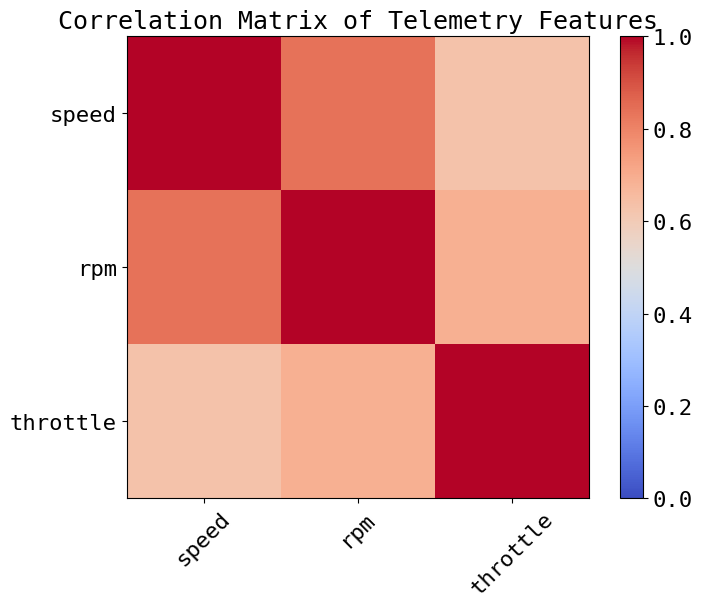

In [ ]:
corr = telem.corr()
print(corr)
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar()
plt.xticks(range(len(telem.columns)), telem.columns, rotation=45)
plt.yticks(range(len(telem.columns)), telem.columns)
plt.title('Correlation Matrix of Telemetry Features');

In [ ]:
names = df['name_acronym'].unique()
names

array(['VER', 'SAR', 'NOR', 'GAS', 'PER', 'ALO', 'LEC', 'STR', 'MAG',
       'TSU', 'ALB', 'ZHO', 'HUL', 'OCO', 'LAW', 'HAM', 'SAI', 'RUS',
       'BOT', 'PIA'], dtype=object)

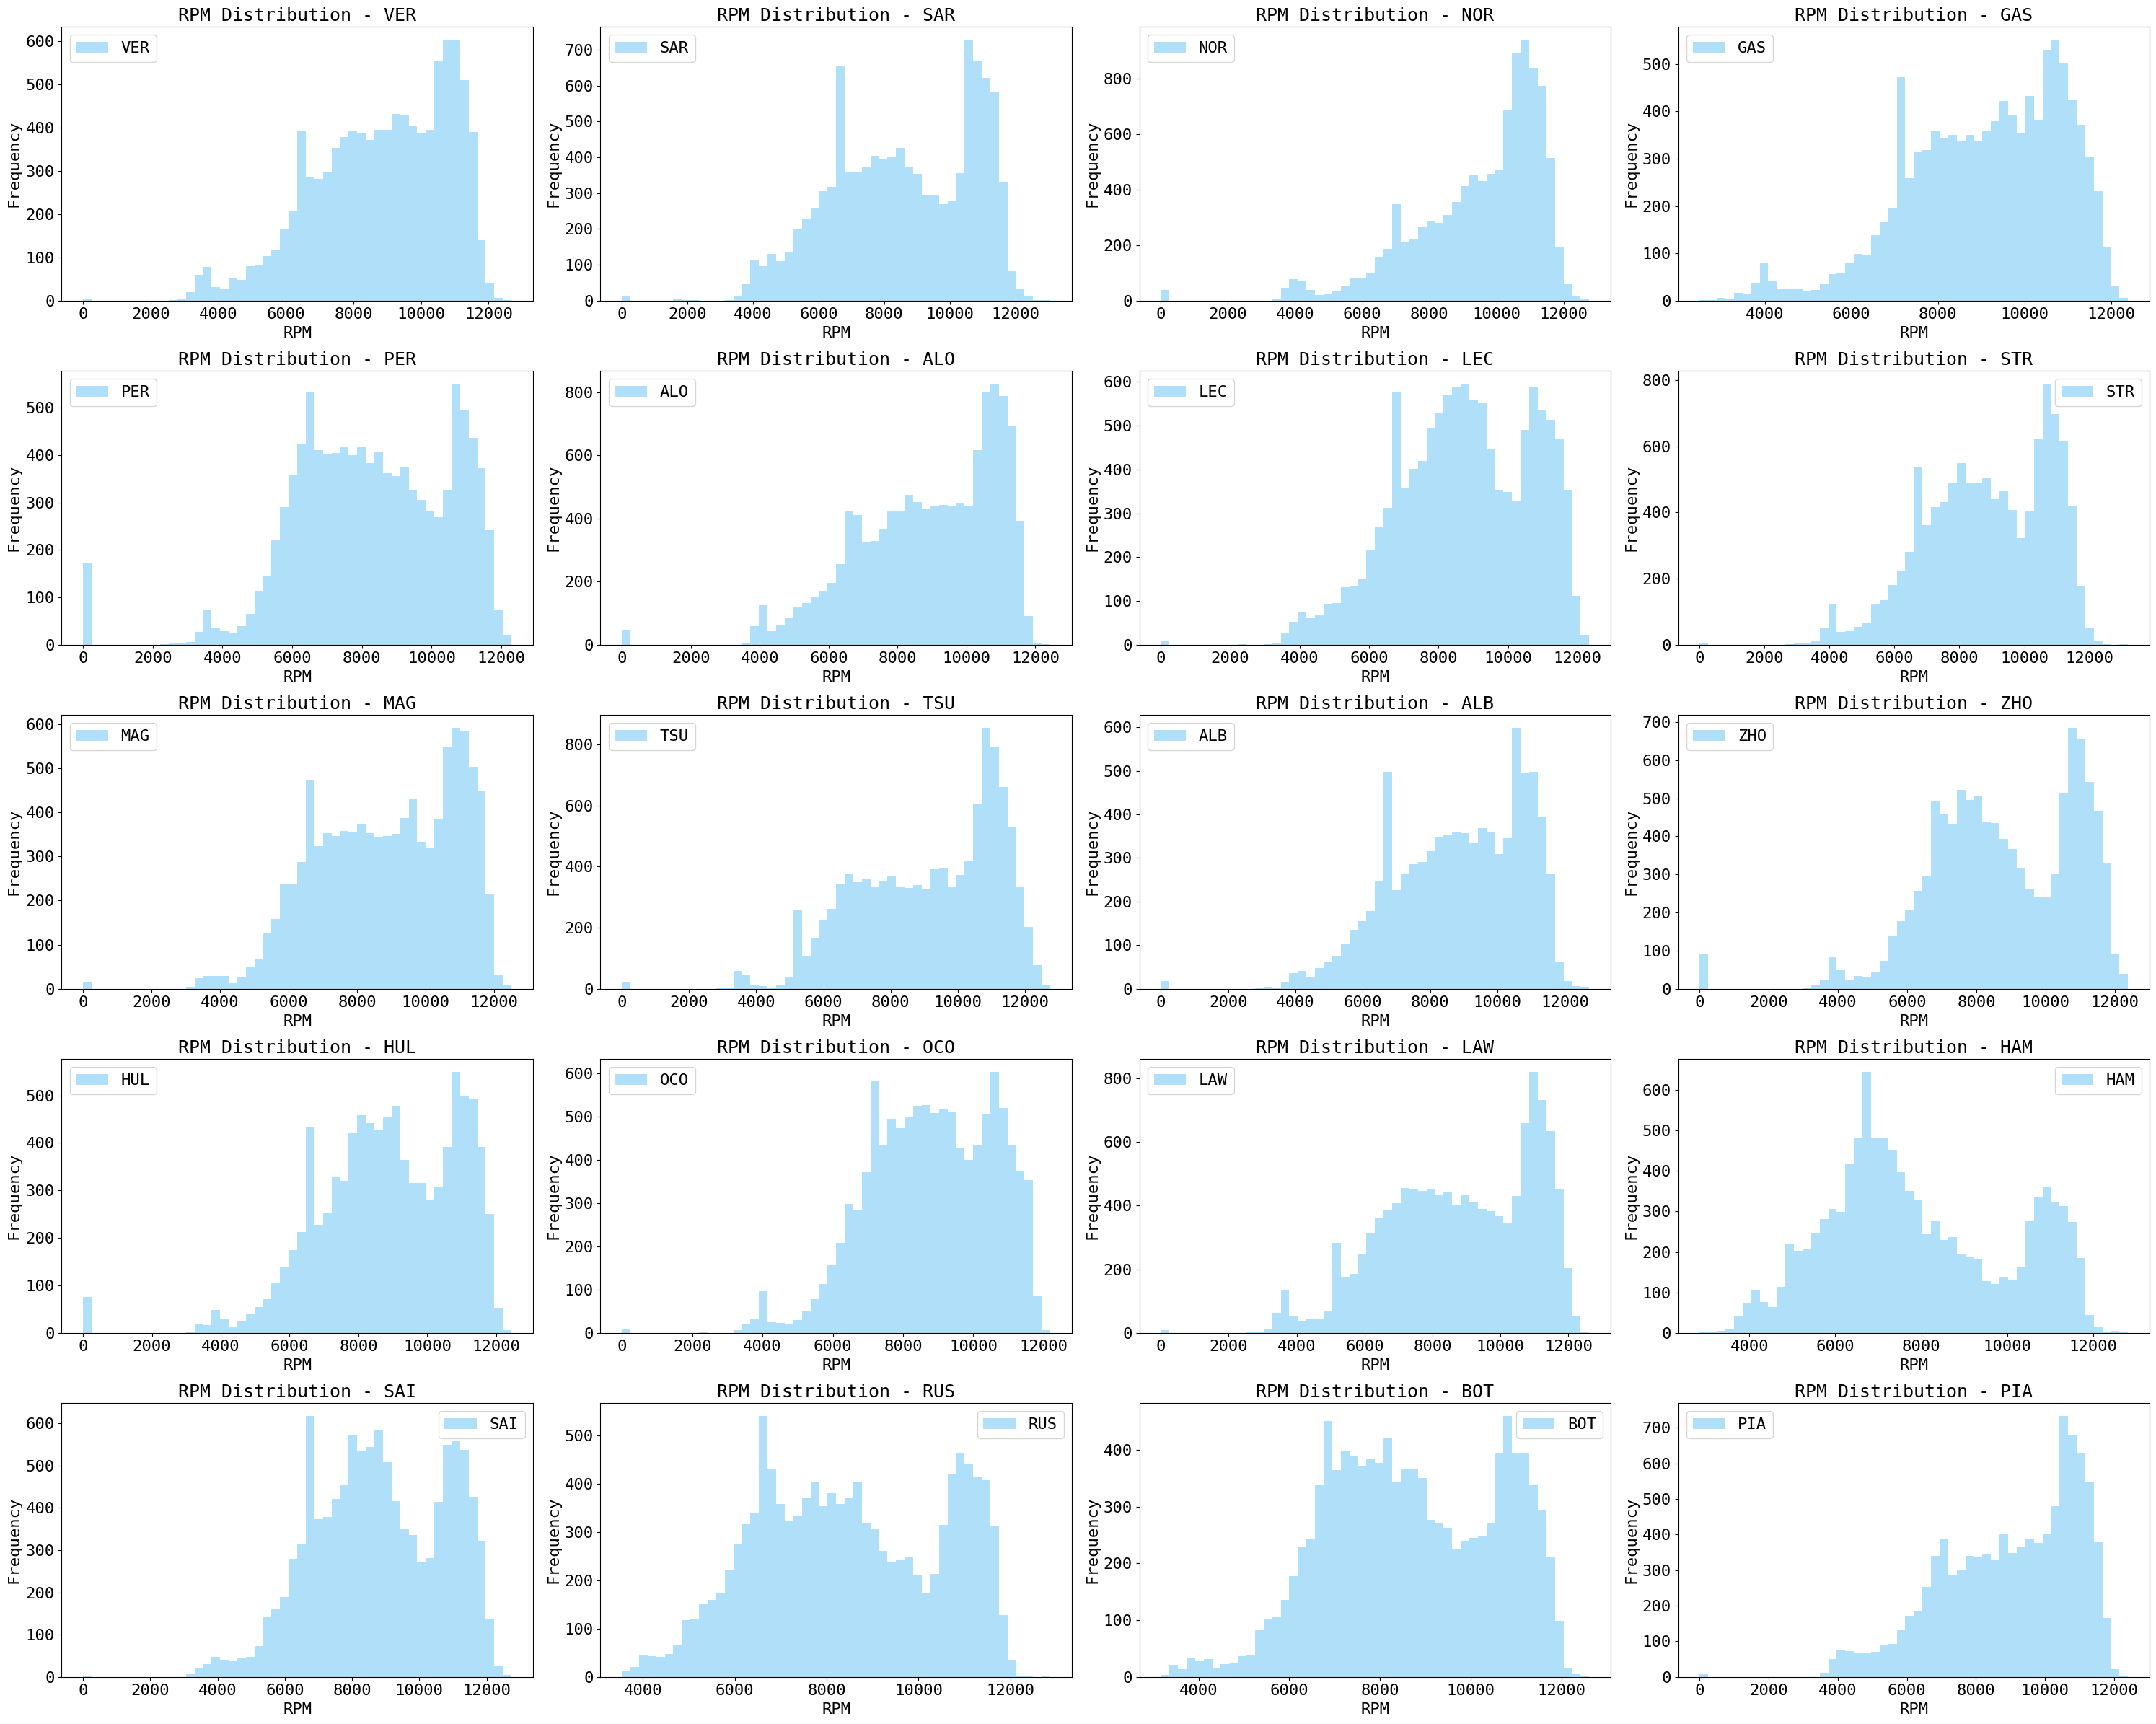

In [ ]:
fig, ax = plt.subplots(nrows=5, ncols=4, figsize=(30, 24))
ax = ax.flatten()
for i, name in enumerate(names):
    name_speed = telem['rpm'].loc[df['name_acronym'] == name]
    ax[i].hist(name_speed, bins=50, alpha=0.5, label=name)
    ax[i].set_xlabel('RPM')
    ax[i].set_ylabel('Frequency')
    ax[i].set_title(f'RPM Distribution - {name}')
    ax[i].legend()
plt.tight_layout()

In [ ]:
scaler = StandardScaler()
telem_scaled = scaler.fit_transform(telem)

In [ ]:
pca = PCA(n_components=2)
y_pcs = pca.fit_transform(telem_scaled)

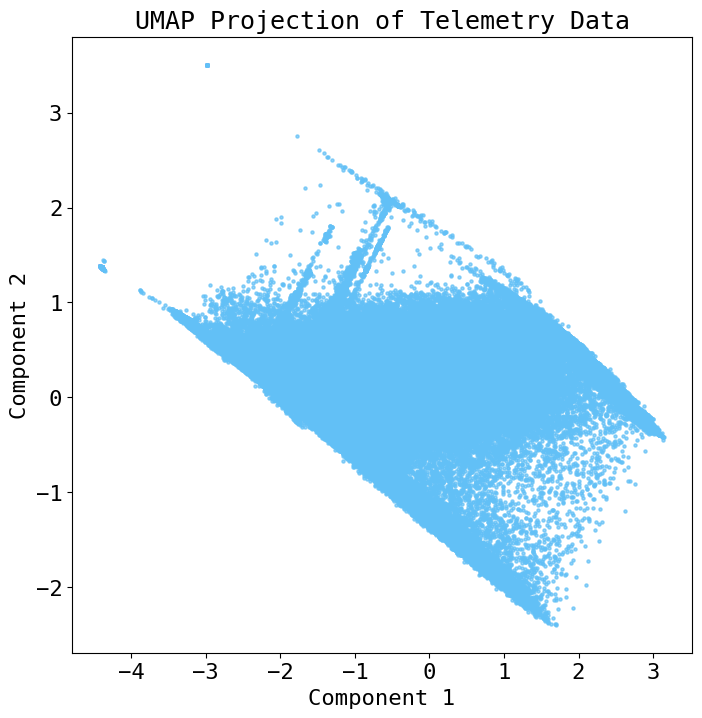

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.scatter(y_pcs[:, 0], y_pcs[:, 1], s=5, alpha=0.7)
ax.set_title('UMAP Projection of Telemetry Data');

In [ ]:
reducer = umap.UMAP(n_components=2)
y_umap = reducer.fit_transform(telem_scaled)

In [ ]:
start = time.time()

km = KMeans(
    n_clusters=20,
    init='k-means++',   # smarter initialization than random
    n_init=20,          # run 20 times, keep best — default is only 10
    max_iter=500,       # give it room to converge
    random_state=42
)
km_labels = km.fit_predict(telem_scaled)

end = time.time()

print(f"Time used by K-Means: {(end - start) * 1000:.1f} ms")

Time used by K-Means: 8375.3 ms


In [ ]:
uniques = np.unique(driver_numbers, return_counts=True)
# for num, count in zip(*uniques):
#     print(f"Driver {num}: {count} samples")
driver_numbers_seq = driver_numbers.astype(int)
sequence_map = {num: i for i, num in enumerate(np.unique(driver_numbers))}

for i, num in enumerate(driver_numbers):
    driver_numbers_seq[driver_numbers_seq == num] = sequence_map[num]

Driver 1: 9893 samples
Driver 2: 10611 samples
Driver 4: 10417 samples
Driver 10: 10464 samples
Driver 11: 10587 samples
Driver 14: 11930 samples
Driver 16: 11892 samples
Driver 18: 11033 samples
Driver 20: 10092 samples
Driver 22: 11012 samples
Driver 23: 8498 samples
Driver 24: 10755 samples
Driver 27: 9481 samples
Driver 31: 11026 samples
Driver 40: 12234 samples
Driver 44: 10655 samples
Driver 55: 11064 samples
Driver 63: 11931 samples
Driver 77: 10906 samples
Driver 81: 9931 samples


In [ ]:
driver_numbers_seq

array([ 0,  0,  0, ..., 19, 19, 19])

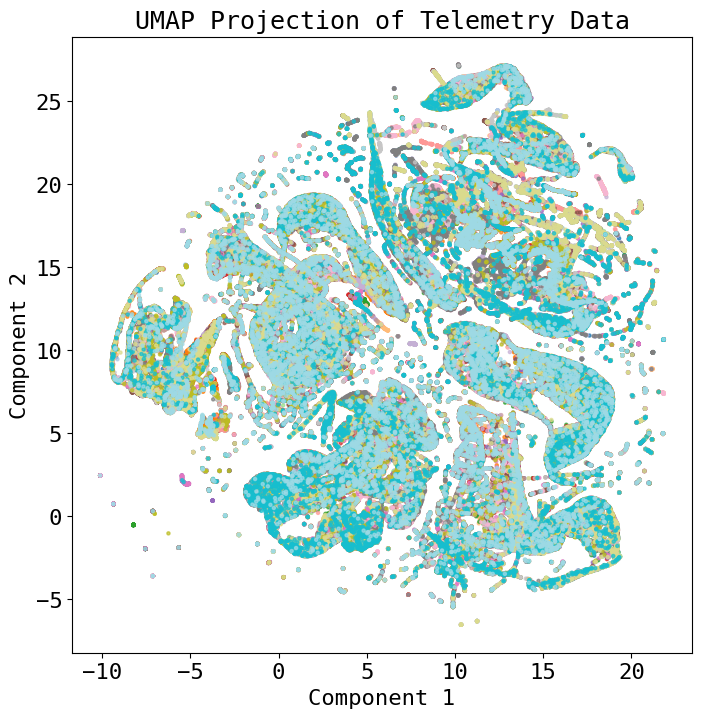

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.scatter(y_umap[:, 0], y_umap[:, 1], s=5, c=driver_numbers_seq, cmap='tab20', alpha=0.7)
ax.set_title('UMAP Projection of Telemetry Data');

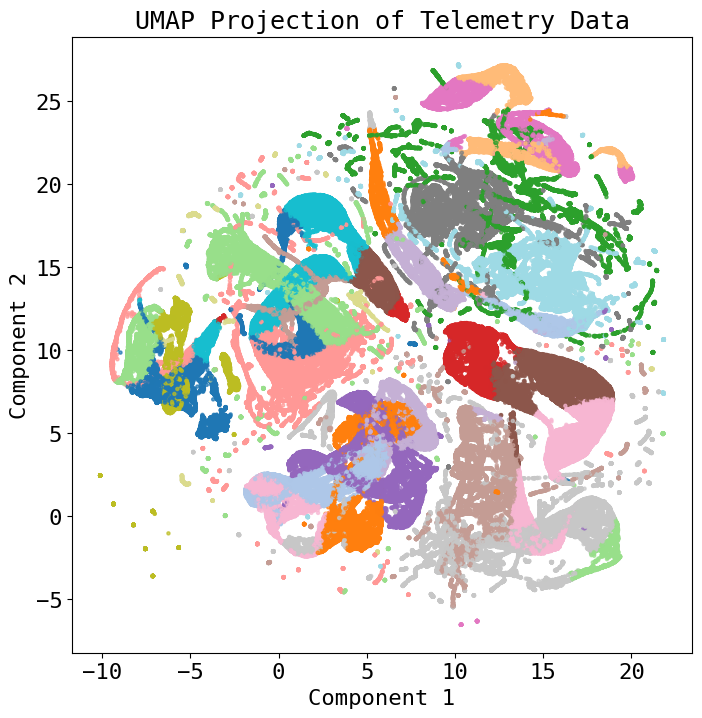

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.scatter(y_umap[:, 0], y_umap[:, 1], s=5, c=km_labels, cmap='tab20', alpha=0.7)
ax.set_title('UMAP Projection of Telemetry Data');

In [ ]:
telem_few = telem[driver_numbers_seq < 2]
telem_few_scaled = scaler.fit_transform(telem_few)

reducer = umap.UMAP(n_components=3)
y_umap_few = reducer.fit_transform(telem_few_scaled)

In [ ]:
start = time.time()

km_few = KMeans(
    n_clusters=2,
    init='k-means++',   # smarter initialization than random
    n_init=20,          # run 20 times, keep best — default is only 10
    max_iter=500,       # give it room to converge
    random_state=42
)
km_labels_few = km_few.fit_predict(telem_few_scaled)

end = time.time()

print(f"Time used by K-Means: {(end - start) * 1000:.1f} ms")

Time used by K-Means: 187.3 ms


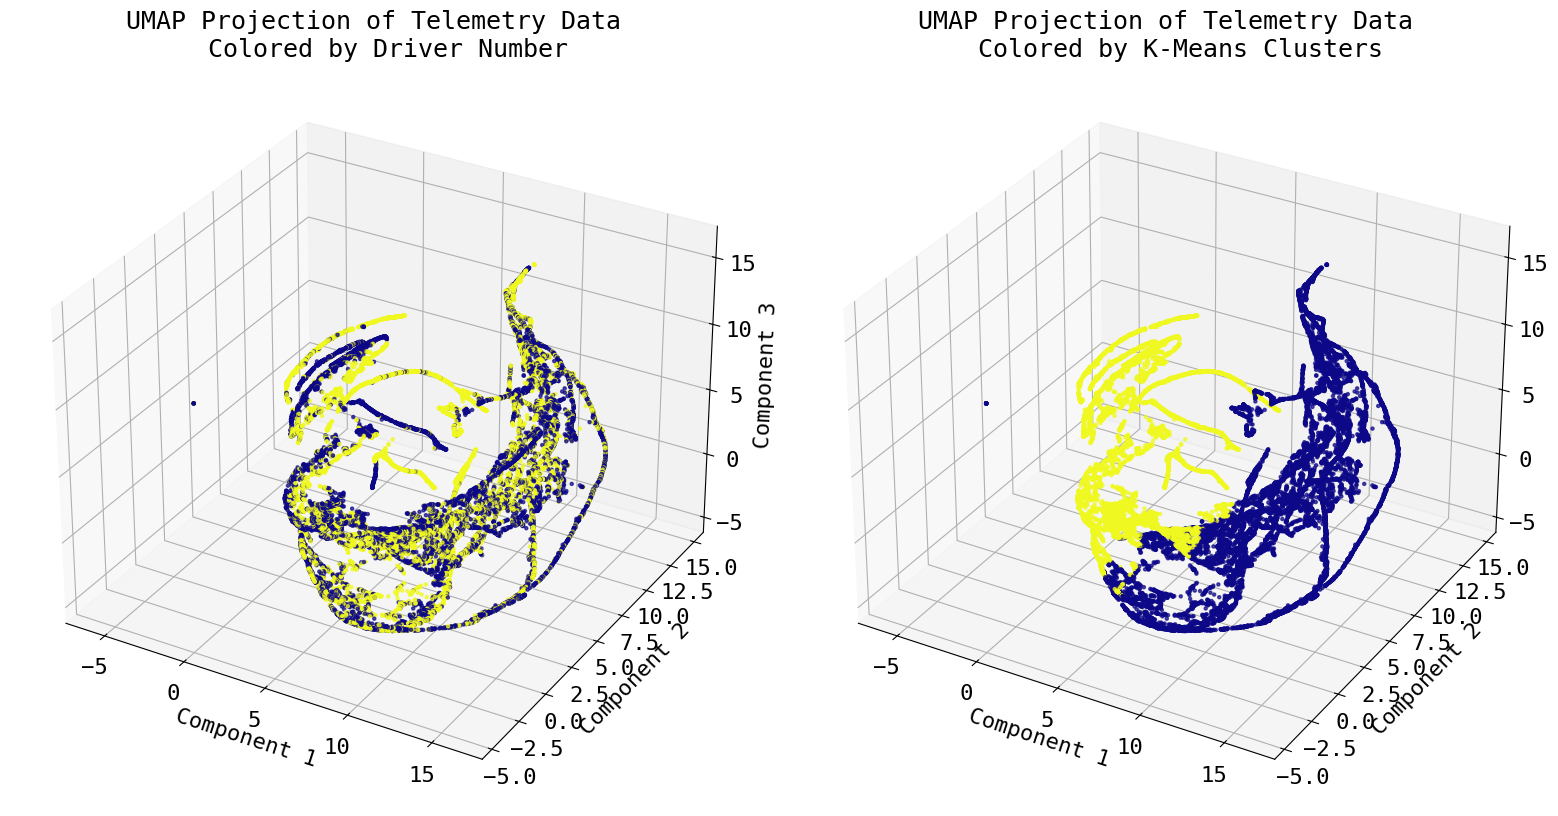

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': '3d'})
ax[0].set_xlabel('Component 1')
ax[0].set_ylabel('Component 2')
ax[0].set_zlabel('Component 3')
ax[0].scatter(y_umap_few[:, 0], y_umap_few[:, 1], y_umap_few[:, 2], s=5, c=driver_numbers_seq[driver_numbers_seq < 2], cmap='plasma', alpha=0.7)
ax[0].set_title('UMAP Projection of Telemetry Data \n Colored by Driver Number')

ax[1].set_xlabel('Component 1')
ax[1].set_ylabel('Component 2')
ax[1].scatter(y_umap_few[:, 0], y_umap_few[:, 1], y_umap_few[:, 2], s=5, c=km_labels_few, cmap='plasma', alpha=0.7)
ax[1].set_title('UMAP Projection of Telemetry Data \n Colored by K-Means Clusters')
plt.tight_layout();